In [1]:
import pandas as pd



In [5]:
df = pd.read_csv('reddit_topic_assignments.csv')
print(df.columns)
##AIAttitude/0109/

Index(['doc_id', 'Document', 'Topic', 'Name', 'Representation',
       'Representative_Docs', 'Top_n_words', 'Probability',
       'Representative_document', 'month', 'subreddit', 'ai_keyword',
       'work_keyword', 'author', 'score', 'num_comments', 'url'],
      dtype='object')


In [6]:
"""

Reddit Sentiment Analysis using Twitter-RoBERTa Model

分析Reddit帖子和评论的情绪变化趋势

"""

 

import pandas as pd

import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification

from scipy.special import softmax

import torch

from tqdm import tqdm

import matplotlib.pyplot as plt

import seaborn as sns

from typing import Dict, List, Tuple

import warnings

warnings.filterwarnings('ignore')

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class RedditSentimentAnalyzer:

    """使用RoBERTa模型分析Reddit文本情绪"""

 

    def __init__(self, model_name: str = "cardiffnlp/twitter-roberta-base-sentiment-latest"):

        """

        初始化情绪分析器

 

        Args:

            model_name: HuggingFace模型名称

        """

        print(f"Loading model: {model_name}")

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

        self.model = AutoModelForSequenceClassification.from_pretrained(model_name)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model.to(self.device)

        self.model.eval()

 

        # 情绪标签

        self.labels = ['negative', 'neutral', 'positive']

        print(f"Model loaded successfully on {self.device}")

 

    def preprocess_text(self, text: str) -> str:

        """

        预处理文本（模仿Twitter预处理）

 

        Args:

            text: 原始文本

 

        Returns:

            预处理后的文本

        """

        if pd.isna(text):

            return ""

 

        text = str(text)

        # 替换URL

        new_text = []

        for t in text.split():

            t = '@user' if t.startswith('@') and len(t) > 1 else t

            t = 'http' if t.startswith('http') else t

            new_text.append(t)

        return " ".join(new_text)

 

    def analyze_sentiment(self, text: str) -> Dict[str, float]:

        """

        分析单条文本的情绪

 

        Args:

            text: 要分析的文本

 

        Returns:

            包含negative, neutral, positive概率的字典

        """

        text = self.preprocess_text(text)

 

        if not text or len(text.strip()) == 0:

            return {label: 0.0 for label in self.labels}

 

        # Tokenize

        encoded_input = self.tokenizer(

            text,

            return_tensors='pt',

            truncation=True,

            max_length=512,

            padding=True

        )

 

        # 移到设备上

        encoded_input = {k: v.to(self.device) for k, v in encoded_input.items()}

 

        # 推理

        with torch.no_grad():

            output = self.model(**encoded_input)

 

        # 获取概率

        scores = output.logits[0].cpu().numpy()

        scores = softmax(scores)

 

        return {label: float(score) for label, score in zip(self.labels, scores)}

 

    def analyze_dataframe(self, df: pd.DataFrame, text_column: str = 'Document',

                         batch_size: int = 32) -> pd.DataFrame:

        """

        批量分析DataFrame中的文本

 

        Args:

            df: 包含文本的DataFrame

            text_column: 文本列名

            batch_size: 批处理大小

 

        Returns:

            添加了情绪分析结果的DataFrame

        """

        print(f"Analyzing {len(df)} documents...")

 

        results = []

        for idx in tqdm(range(0, len(df), batch_size)):

            batch = df[text_column].iloc[idx:idx+batch_size]

 

            for text in batch:

                sentiment = self.analyze_sentiment(text)

                results.append(sentiment)

 

        # 添加情绪列

        sentiment_df = pd.DataFrame(results)

        df_with_sentiment = df.copy()

        df_with_sentiment['sentiment_negative'] = sentiment_df['negative']

        df_with_sentiment['sentiment_neutral'] = sentiment_df['neutral']

        df_with_sentiment['sentiment_positive'] = sentiment_df['positive']

 

        # 添加主导情绪标签

        df_with_sentiment['sentiment_label'] = sentiment_df.idxmax(axis=1)

 

        # 添加情绪得分（positive - negative）

        df_with_sentiment['sentiment_score'] = (

            sentiment_df['positive'] - sentiment_df['negative']

        )

 

        print("Analysis complete!")

        return df_with_sentiment

 

 

class SentimentVisualizer:

    """可视化情绪分析结果"""

 

    def __init__(self, df: pd.DataFrame):

        """

        初始化可视化器

 

        Args:

            df: 包含情绪分析结果的DataFrame

        """

        self.df = df

        plt.style.use('seaborn-v0_8-darkgrid')

        sns.set_palette("husl")

 

    def plot_sentiment_over_time(self, time_column: str = 'month',

                                 figsize: Tuple[int, int] = (14, 6)):

        """

        绘制情绪随时间的变化趋势

 

        Args:

            time_column: 时间列名

            figsize: 图表大小

        """

        fig, axes = plt.subplots(1, 2, figsize=figsize)

 

        # 按时间聚合

        time_sentiment = self.df.groupby(time_column).agg({

            'sentiment_negative': 'mean',

            'sentiment_neutral': 'mean',

            'sentiment_positive': 'mean',

            'sentiment_score': 'mean'

        }).reset_index()

 

        # 图1: 三种情绪的变化

        ax1 = axes[0]

        ax1.plot(time_sentiment[time_column], time_sentiment['sentiment_negative'],

                marker='o', label='Negative', linewidth=2)

        ax1.plot(time_sentiment[time_column], time_sentiment['sentiment_neutral'],

                marker='s', label='Neutral', linewidth=2)

        ax1.plot(time_sentiment[time_column], time_sentiment['sentiment_positive'],

                marker='^', label='Positive', linewidth=2)

        ax1.set_xlabel('Time', fontsize=12)

        ax1.set_ylabel('Average Probability', fontsize=12)

        ax1.set_title('Sentiment Distribution Over Time', fontsize=14, fontweight='bold')

        ax1.legend()

        ax1.grid(True, alpha=0.3)

        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

 

        # 图2: 情绪得分（正面-负面）

        ax2 = axes[1]

        ax2.plot(time_sentiment[time_column], time_sentiment['sentiment_score'],

                marker='o', color='purple', linewidth=2)

        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

        ax2.fill_between(time_sentiment[time_column],

                        time_sentiment['sentiment_score'], 0,

                        where=(time_sentiment['sentiment_score'] >= 0),

                        alpha=0.3, color='green', label='Positive')

        ax2.fill_between(time_sentiment[time_column],

                        time_sentiment['sentiment_score'], 0,

                        where=(time_sentiment['sentiment_score'] < 0),

                        alpha=0.3, color='red', label='Negative')

        ax2.set_xlabel('Time', fontsize=12)

        ax2.set_ylabel('Sentiment Score (Positive - Negative)', fontsize=12)

        ax2.set_title('Net Sentiment Score Over Time', fontsize=14, fontweight='bold')

        ax2.legend()

        ax2.grid(True, alpha=0.3)

        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

 

        plt.tight_layout()

        return fig

 

    def plot_sentiment_by_topic(self, topic_column: str = 'Topic',

                                top_n: int = 10,

                                figsize: Tuple[int, int] = (12, 8)):

        """

        绘制不同主题的情绪分布

 

        Args:

            topic_column: 主题列名

            top_n: 显示前N个主题

            figsize: 图表大小

        """

        # 按主题聚合

        topic_sentiment = self.df.groupby(topic_column).agg({

            'sentiment_negative': 'mean',

            'sentiment_neutral': 'mean',

            'sentiment_positive': 'mean',

            'sentiment_score': 'mean',

            'Document': 'count'

        }).reset_index()

 

        topic_sentiment.columns = [topic_column, 'negative', 'neutral',

                                   'positive', 'score', 'count']

 

        # 按文档数量排序，取前N个

        topic_sentiment = topic_sentiment.nlargest(top_n, 'count')

 

        fig, axes = plt.subplots(2, 1, figsize=figsize)

 

        # 图1: 堆叠条形图

        ax1 = axes[0]

        x = range(len(topic_sentiment))

        width = 0.8

 

        ax1.bar(x, topic_sentiment['negative'], width, label='Negative', color='#FF6B6B')

        ax1.bar(x, topic_sentiment['neutral'], width,

               bottom=topic_sentiment['negative'], label='Neutral', color='#95E1D3')

        ax1.bar(x, topic_sentiment['positive'], width,

               bottom=topic_sentiment['negative'] + topic_sentiment['neutral'],

               label='Positive', color='#4ECDC4')

 

        ax1.set_xlabel('Topic', fontsize=12)

        ax1.set_ylabel('Probability', fontsize=12)

        ax1.set_title(f'Sentiment Distribution by Topic (Top {top_n})',

                     fontsize=14, fontweight='bold')

        ax1.set_xticks(x)

        ax1.set_xticklabels(topic_sentiment[topic_column], rotation=45, ha='right')

        ax1.legend()

        ax1.grid(True, alpha=0.3, axis='y')

 

        # 图2: 情绪得分

        ax2 = axes[1]

        colors = ['green' if score >= 0 else 'red' for score in topic_sentiment['score']]

        bars = ax2.barh(range(len(topic_sentiment)), topic_sentiment['score'], color=colors, alpha=0.7)

        ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

        ax2.set_yticks(range(len(topic_sentiment)))

        ax2.set_yticklabels(topic_sentiment[topic_column])

        ax2.set_xlabel('Sentiment Score (Positive - Negative)', fontsize=12)

        ax2.set_title('Net Sentiment by Topic', fontsize=14, fontweight='bold')

        ax2.grid(True, alpha=0.3, axis='x')

 

        plt.tight_layout()

        return fig

 

    def plot_sentiment_by_subreddit(self, subreddit_column: str = 'subreddit',

                                   top_n: int = 15,

                                   figsize: Tuple[int, int] = (14, 8)):

        """

        绘制不同subreddit的情绪对比

 

        Args:

            subreddit_column: subreddit列名

            top_n: 显示前N个subreddit

            figsize: 图表大小

        """

        # 按subreddit聚合

        subreddit_sentiment = self.df.groupby(subreddit_column).agg({

            'sentiment_score': 'mean',

            'sentiment_positive': 'mean',

            'sentiment_negative': 'mean',

            'Document': 'count'

        }).reset_index()

 

        subreddit_sentiment.columns = [subreddit_column, 'score', 'positive',

                                       'negative', 'count']

 

        # 取前N个

        subreddit_sentiment = subreddit_sentiment.nlargest(top_n, 'count')

        subreddit_sentiment = subreddit_sentiment.sort_values('score')

 

        fig, ax = plt.subplots(figsize=figsize)

 

        y_pos = range(len(subreddit_sentiment))

        colors = ['#2ecc71' if score >= 0 else '#e74c3c'

                 for score in subreddit_sentiment['score']]

 

        bars = ax.barh(y_pos, subreddit_sentiment['score'], color=colors, alpha=0.7)

        ax.set_yticks(y_pos)

        ax.set_yticklabels(subreddit_sentiment[subreddit_column])

        ax.set_xlabel('Average Sentiment Score', fontsize=12)

        ax.set_title(f'Sentiment by Subreddit (Top {top_n} by Volume)',

                    fontsize=14, fontweight='bold')

        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

        ax.grid(True, alpha=0.3, axis='x')

 

        # 添加数值标签

        for i, (bar, score) in enumerate(zip(bars, subreddit_sentiment['score'])):

            width = bar.get_width()

            label_x_pos = width + 0.01 if width > 0 else width - 0.01

            ax.text(label_x_pos, bar.get_y() + bar.get_height()/2,

                   f'{score:.3f}',

                   va='center', ha='left' if width > 0 else 'right', fontsize=9)

 

        plt.tight_layout()

        return fig

 

    def plot_sentiment_heatmap(self, time_column: str = 'month',

                              group_column: str = 'Topic',

                              top_n: int = 10,

                              figsize: Tuple[int, int] = (14, 8)):

        """

        绘制情绪热力图（时间 x 分组）

 

        Args:

            time_column: 时间列名

            group_column: 分组列名

            top_n: 显示前N个分组

            figsize: 图表大小

        """

        # 获取top N分组

        top_groups = self.df[group_column].value_counts().head(top_n).index

        df_filtered = self.df[self.df[group_column].isin(top_groups)]

 

        # 创建透视表

        pivot_data = df_filtered.pivot_table(

            values='sentiment_score',

            index=group_column,

            columns=time_column,

            aggfunc='mean'

        )

 

        fig, ax = plt.subplots(figsize=figsize)

        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn',

                   center=0, ax=ax, cbar_kws={'label': 'Sentiment Score'})

        ax.set_title(f'Sentiment Heatmap: {group_column} over {time_column}',

                    fontsize=14, fontweight='bold')

        ax.set_xlabel(time_column.capitalize(), fontsize=12)

        ax.set_ylabel(group_column.capitalize(), fontsize=12)

 

        plt.tight_layout()

        return fig

 

    def generate_summary_statistics(self) -> pd.DataFrame:

        """

        生成情绪分析的汇总统计

 

        Returns:

            汇总统计DataFrame

        """

        summary = pd.DataFrame({

            'Metric': [

                'Total Documents',

                'Average Sentiment Score',

                'Std Sentiment Score',

                'Most Positive Ratio',

                'Most Neutral Ratio',

                'Most Negative Ratio',

                'Positive Documents',

                'Neutral Documents',

                'Negative Documents'

            ],

            'Value': [

                len(self.df),

                self.df['sentiment_score'].mean(),

                self.df['sentiment_score'].std(),

                self.df['sentiment_positive'].mean(),

                self.df['sentiment_neutral'].mean(),

                self.df['sentiment_negative'].mean(),

                (self.df['sentiment_label'] == 'positive').sum(),

                (self.df['sentiment_label'] == 'neutral').sum(),

                (self.df['sentiment_label'] == 'negative').sum()

            ]

        })

 

        return summary

 

 

def main():

    """示例使用"""

    # 1. 初始化分析器

    analyzer = RedditSentimentAnalyzer()

 

    # 2. 读取数据（根据你的文件格式调整）

    # df = pd.read_csv('your_reddit_data.csv')

    # df = pd.read_parquet('your_reddit_data.parquet')

 

    # 示例数据

    print("\n使用示例数据进行测试...")

    df = pd.DataFrame({

        'doc_id': range(5),

        'Document': [

            "AI is revolutionizing the workplace! Excited about the future.",

            "I lost my job due to automation. This is terrible.",

            "The technology is advancing but we need to be careful.",

            "Amazing developments in AI this month!",

            "Worried about the impact on workers."

        ],

        'Topic': ['AI', 'Work', 'Tech', 'AI', 'Work'],

        'month': ['2024-01', '2024-01', '2024-02', '2024-02', '2024-03'],

        'subreddit': ['technology', 'jobs', 'technology', 'futurology', 'jobs']

    })

 

    # 3. 执行情绪分析

    df_analyzed = analyzer.analyze_dataframe(df, text_column='Document')

 

    # 4. 查看结果

    print("\n分析结果预览:")

    print(df_analyzed[['Document', 'sentiment_label', 'sentiment_score',

                      'sentiment_positive', 'sentiment_neutral', 'sentiment_negative']].head())

 

    # 5. 生成可视化

    visualizer = SentimentVisualizer(df_analyzed)

 

    print("\n生成汇总统计...")

    summary = visualizer.generate_summary_statistics()

    print(summary)

 

    # 6. 保存结果

    output_file = 'reddit_sentiment_results.csv'

    df_analyzed.to_csv(output_file, index=False)

    print(f"\n结果已保存到: {output_file}")

 

    print("\n分析完成!")

 

 

if __name__ == "__main__":

    main()

 

Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded successfully on cuda

使用示例数据进行测试...
Analyzing 5 documents...


100%|██████████| 1/1 [00:00<00:00,  4.19it/s]

Analysis complete!

分析结果预览:
                                            Document sentiment_label  \
0  AI is revolutionizing the workplace! Excited a...        positive   
1  I lost my job due to automation. This is terri...        negative   
2  The technology is advancing but we need to be ...         neutral   
3             Amazing developments in AI this month!        positive   
4               Worried about the impact on workers.        negative   

   sentiment_score  sentiment_positive  sentiment_neutral  sentiment_negative  
0         0.986684            0.989011           0.008661            0.002328  
1        -0.939858            0.006900           0.046343            0.946758  
2         0.362050            0.403077           0.555896            0.041027  
3         0.976664            0.980920           0.014825            0.004255  
4        -0.643295            0.015390           0.325925            0.658685  

生成汇总统计...
                    Metric     Value
0          

In [8]:
#from reddit_sentiment_analysis import RedditSentimentAnalyzer, SentimentVisualizer
import pandas as pd

# 1. 加载你的数据
df = pd.read_csv('reddit_topic_assignments.csv') 

df['month_dt'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')

df['quarter'] = df['month_dt'].dt.to_period('Q').astype(str)
print("=" * 60)

print("步骤3: 执行情绪分析")

print("=" * 60)

analyzer = RedditSentimentAnalyzer()

df_analyzed = analyzer.analyze_dataframe(df, text_column='Document', batch_size=32)

print()

# 2. 分析情绪
analyzer = RedditSentimentAnalyzer()
df_analyzed = analyzer.analyze_dataframe(df, text_column='Document')

print("=" * 60)

print("步骤4: 保存详细分析结果")

print("=" * 60)

 

# 4.1 查看前10条结果

print("\n前10条记录的情绪分析结果:")

print("-" * 120)

result_cols = ['doc_id', 'Document', 'Topic', 'quarter', 'subreddit',

               'sentiment_label', 'sentiment_score',

               'sentiment_positive', 'sentiment_neutral', 'sentiment_negative']
output_file = 'reddit_sentiment_detailed_results.csv'

df_analyzed.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ 完整结果已保存到: {output_file}")

print(f"   包含所有 {len(df_analyzed)} 条记录的详细情绪数值\n")

 

# ==================== 5. 生成汇总统计 ====================

print("=" * 60)

print("步骤5: 生成汇总统计")

print("=" * 60)

 

visualizer = SentimentVisualizer(df_analyzed)

summary_stats = visualizer.generate_summary_statistics()

print("\n整体汇总统计:")

print("-" * 60)

print(summary_stats.to_string(index=False))

print()

 

# 5.1 按季度汇总

print("\n按季度的情绪统计:")

print("-" * 100)

quarterly_summary = df_analyzed.groupby('quarter').agg({

    'sentiment_score': ['mean', 'std', 'min', 'max'],

    'sentiment_positive': 'mean',

    'sentiment_neutral': 'mean',

    'sentiment_negative': 'mean',

    'Document': 'count'

}).round(4)

quarterly_summary.columns = ['平均得分', '得分标准差', '最低得分', '最高得分',

                              '平均正面概率', '平均中性概率', '平均负面概率', '文档数']

print(quarterly_summary)

quarterly_summary.to_csv('quarterly_sentiment_summary.csv', encoding='utf-8-sig')

print(f"\n✅ 季度汇总已保存到: quarterly_sentiment_summary.csv\n")

 

# 5.2 按主题汇总

print("\n按主题的情绪统计 (Top 15):")

print("-" * 100)

topic_summary = df_analyzed.groupby('Topic').agg({

    'sentiment_score': ['mean', 'std'],

    'sentiment_positive': 'mean',

    'sentiment_neutral': 'mean',

    'sentiment_negative': 'mean',

    'Document': 'count'

}).round(4)

topic_summary.columns = ['平均得分', '得分标准差', '平均正面', '平均中性', '平均负面', '文档数']

topic_summary = topic_summary.sort_values('文档数', ascending=False).head(15)

print(topic_summary)

topic_summary.to_csv('topic_sentiment_summary.csv', encoding='utf-8-sig')

print(f"\n✅ 主题汇总已保存到: topic_sentiment_summary.csv\n")

 

# 5.3 按subreddit汇总

if 'subreddit' in df_analyzed.columns:

    print("\n按Subreddit的情绪统计 (Top 15):")

    print("-" * 100)

    subreddit_summary = df_analyzed.groupby('subreddit').agg({

        'sentiment_score': ['mean', 'std'],

        'sentiment_positive': 'mean',

        'sentiment_negative': 'mean',

        'Document': 'count'

    }).round(4)

    subreddit_summary.columns = ['平均得分', '得分标准差', '平均正面', '平均负面', '文档数']

    subreddit_summary = subreddit_summary.sort_values('文档数', ascending=False).head(15)

    print(subreddit_summary)

    subreddit_summary.to_csv('subreddit_sentiment_summary.csv', encoding='utf-8-sig')

    print(f"\n✅ Subreddit汇总已保存到: subreddit_sentiment_summary.csv\n")

 

# 5.4 情绪分布统计

print("\n情绪标签分布:")

print("-" * 60)

label_dist = df_analyzed['sentiment_label'].value_counts()

label_dist_pct = df_analyzed['sentiment_label'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({

    '数量': label_dist,

    '百分比': label_dist_pct.round(2)

})

print(dist_df)

print()



步骤3: 执行情绪分析
Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded successfully on cuda
Analyzing 6566 documents...


100%|██████████| 206/206 [01:37<00:00,  2.11it/s]


Analysis complete!

Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Model loaded successfully on cuda
Analyzing 6566 documents...


100%|██████████| 206/206 [01:47<00:00,  1.92it/s]


Analysis complete!
步骤4: 保存详细分析结果

前10条记录的情绪分析结果:
------------------------------------------------------------------------------------------------------------------------
✅ 完整结果已保存到: reddit_sentiment_detailed_results.csv
   包含所有 6566 条记录的详细情绪数值

步骤5: 生成汇总统计

整体汇总统计:
------------------------------------------------------------
                 Metric       Value
        Total Documents 6566.000000
Average Sentiment Score   -0.081057
    Std Sentiment Score    0.514943
    Most Positive Ratio    0.227227
     Most Neutral Ratio    0.464489
    Most Negative Ratio    0.308284
     Positive Documents 1211.000000
      Neutral Documents 3180.000000
     Negative Documents 2175.000000


按季度的情绪统计:
----------------------------------------------------------------------------------------------------
           平均得分   得分标准差    最低得分    最高得分  平均正面概率  平均中性概率  平均负面概率   文档数
quarter                                                              
NaT     -0.0811  0.5149 -0.9391  0.9849  0.2272  0.4645  0.3

In [9]:
print("=" * 60)

print("步骤6: 生成静态图表")

print("=" * 60)

 

# 6.1 季度趋势图

print("\n生成图表1: 情绪季度趋势...")

fig1 = visualizer.plot_sentiment_over_time(time_column='quarter', figsize=(14, 6))

plt.savefig('sentiment_by_quarter.png', dpi=300, bbox_inches='tight')

print("✅ 已保存: sentiment_by_quarter.png")

plt.close()

 

# 6.2 主题对比图

print("生成图表2: 主题情绪对比...")

fig2 = visualizer.plot_sentiment_by_topic(topic_column='Topic', top_n=15, figsize=(14, 10))

plt.savefig('sentiment_by_topic.png', dpi=300, bbox_inches='tight')

print("✅ 已保存: sentiment_by_topic.png")

plt.close()

 

# 6.3 Subreddit对比图

if 'subreddit' in df_analyzed.columns:

    print("生成图表3: Subreddit情绪对比...")

    fig3 = visualizer.plot_sentiment_by_subreddit(subreddit_column='subreddit',

                                                   top_n=15, figsize=(14, 10))

    plt.savefig('sentiment_by_subreddit.png', dpi=300, bbox_inches='tight')

    print("✅ 已保存: sentiment_by_subreddit.png")

    plt.close()

 

# 6.4 热力图

print("生成图表4: 主题-季度热力图...")

fig4 = visualizer.plot_sentiment_heatmap(time_column='quarter',

                                         group_column='Topic',

                                         top_n=10, figsize=(14, 8))

plt.savefig('sentiment_heatmap_quarter_topic.png', dpi=300, bbox_inches='tight')

print("✅ 已保存: sentiment_heatmap_quarter_topic.png")

plt.close()

 

print()

 

# ==================== 7. 生成交互式图表 ====================

print("=" * 60)

print("步骤7: 生成交互式图表 (Plotly)")

print("=" * 60)

 

try:

    import plotly.graph_objects as go

    import plotly.express as px

    from plotly.subplots import make_subplots

 

    # 7.1 交互式季度趋势图

    print("\n生成交互式图表1: 季度情绪趋势...")

    quarterly_data = df_analyzed.groupby('quarter').agg({

        'sentiment_negative': 'mean',

        'sentiment_neutral': 'mean',

        'sentiment_positive': 'mean',

        'sentiment_score': 'mean',

        'Document': 'count'

    }).reset_index()

 

    fig = make_subplots(

        rows=2, cols=1,

        subplot_titles=('情绪概率随季度变化', '净情绪得分随季度变化'),

        vertical_spacing=0.15

    )

 

    # 上图：三种情绪

    fig.add_trace(go.Scatter(x=quarterly_data['quarter'],

                            y=quarterly_data['sentiment_positive'],

                            mode='lines+markers', name='Positive',

                            line=dict(color='green', width=3),

                            marker=dict(size=8)), row=1, col=1)

    fig.add_trace(go.Scatter(x=quarterly_data['quarter'],

                            y=quarterly_data['sentiment_neutral'],

                            mode='lines+markers', name='Neutral',

                            line=dict(color='gray', width=3),

                            marker=dict(size=8)), row=1, col=1)

    fig.add_trace(go.Scatter(x=quarterly_data['quarter'],

                            y=quarterly_data['sentiment_negative'],

                            mode='lines+markers', name='Negative',

                            line=dict(color='red', width=3),

                            marker=dict(size=8)), row=1, col=1)

 

    # 下图：净得分

    fig.add_trace(go.Scatter(x=quarterly_data['quarter'],

                            y=quarterly_data['sentiment_score'],

                            mode='lines+markers', name='Sentiment Score',

                            line=dict(color='purple', width=3),

                            marker=dict(size=8),

                            fill='tozeroy'), row=2, col=1)

    fig.add_hline(y=0, line_dash="dash", line_color="red", row=2, col=1)

 

    fig.update_xaxes(title_text="Quarter", row=2, col=1)

    fig.update_yaxes(title_text="Probability", row=1, col=1)

    fig.update_yaxes(title_text="Sentiment Score", row=2, col=1)

    fig.update_layout(height=800, title_text="Reddit情绪分析 - 季度趋势", showlegend=True)

 

    fig.write_html('interactive_sentiment_quarterly.html')

    print("✅ 已保存: interactive_sentiment_quarterly.html")

 

    # 7.2 交互式主题对比

    print("生成交互式图表2: 主题情绪对比...")

    topic_data = df_analyzed.groupby('Topic').agg({

        'sentiment_score': 'mean',

        'sentiment_positive': 'mean',

        'sentiment_negative': 'mean',

        'Document': 'count'

    }).reset_index()

    topic_data = topic_data.nlargest(20, 'Document')

 

    fig2 = go.Figure()

    colors = ['green' if score >= 0 else 'red' for score in topic_data['sentiment_score']]

 

    fig2.add_trace(go.Bar(

        y=topic_data['Topic'],

        x=topic_data['sentiment_score'],

        orientation='h',

        marker_color=colors,

        text=topic_data['sentiment_score'].round(3),

        textposition='outside',

        hovertemplate='<b>%{y}</b><br>' +

                     'Sentiment Score: %{x:.3f}<br>' +

                     'Documents: %{customdata}<br>' +

                     '<extra></extra>',

        customdata=topic_data['Document']

    ))

 

    fig2.add_vline(x=0, line_dash="dash", line_color="black", line_width=2)

    fig2.update_layout(

        title='主题情绪得分对比 (Top 20)',

        xaxis_title='Sentiment Score',

        yaxis_title='Topic',

        height=800,

        showlegend=False

    )

 

    fig2.write_html('interactive_sentiment_by_topic.html')

    print("✅ 已保存: interactive_sentiment_by_topic.html")

 

    # 7.3 交互式热力图

    print("生成交互式图表3: 主题-季度热力图...")

    top_topics = df_analyzed['Topic'].value_counts().head(15).index

    pivot_data = df_analyzed[df_analyzed['Topic'].isin(top_topics)].pivot_table(

        values='sentiment_score',

        index='Topic',

        columns='quarter',

        aggfunc='mean'

    )

 

    fig3 = go.Figure(data=go.Heatmap(

        z=pivot_data.values,

        x=pivot_data.columns,

        y=pivot_data.index,

        colorscale='RdYlGn',

        zmid=0,

        text=pivot_data.values.round(3),

        texttemplate='%{text}',

        textfont={"size": 10},

        colorbar=dict(title="Sentiment<br>Score")

    ))

 

    fig3.update_layout(

        title='主题-季度情绪热力图',

        xaxis_title='Quarter',

        yaxis_title='Topic',

        height=700

    )

 

    fig3.write_html('interactive_heatmap_quarter_topic.html')

    print("✅ 已保存: interactive_heatmap_quarter_topic.html")

 

    # 7.4 情绪分布饼图

    print("生成交互式图表4: 情绪分布...")

    label_counts = df_analyzed['sentiment_label'].value_counts()

 

    fig4 = go.Figure(data=[go.Pie(

        labels=label_counts.index,

        values=label_counts.values,

        hole=.3,

        marker_colors=['green', 'gray', 'red']

    )])

 

    fig4.update_layout(title='情绪标签分布')

    fig4.write_html('interactive_sentiment_distribution.html')

    print("✅ 已保存: interactive_sentiment_distribution.html")

 

    print("\n✅ 所有交互式图表生成完成!")

 

except ImportError:

    print("\n⚠️  Plotly未安装，跳过交互式图表生成")

    print("   安装命令: pip install plotly")

 

# ==================== 8. 生成最终报告 ====================

print("\n" + "=" * 60)

print("分析完成! 生成的文件汇总")

print("=" * 60)

 

print("\n📊 数据文件:")

print("  1. reddit_sentiment_detailed_results.csv - 每条记录的详细情绪数值")

print("  2. quarterly_sentiment_summary.csv - 季度汇总统计")

print("  3. topic_sentiment_summary.csv - 主题汇总统计")

if 'subreddit' in df_analyzed.columns:

    print("  4. subreddit_sentiment_summary.csv - Subreddit汇总统计")

 

print("\n📈 静态图表 (高分辨率PNG):")

print("  1. sentiment_by_quarter.png - 季度情绪趋势")

print("  2. sentiment_by_topic.png - 主题情绪对比")

if 'subreddit' in df_analyzed.columns:

    print("  3. sentiment_by_subreddit.png - Subreddit对比")

print("  4. sentiment_heatmap_quarter_topic.png - 热力图")

 

print("\n🎯 交互式图表 (HTML文件，可在浏览器中打开):")

print("  1. interactive_sentiment_quarterly.html - 季度趋势（可交互）")

print("  2. interactive_sentiment_by_topic.html - 主题对比（可交互）")

print("  3. interactive_heatmap_quarter_topic.html - 热力图（可交互）")

print("  4. interactive_sentiment_distribution.html - 情绪分布（可交互）")

 

print("\n" + "=" * 60)

print("✅ 所有分析完成!")

print("=" * 60)

步骤6: 生成静态图表

生成图表1: 情绪季度趋势...
✅ 已保存: sentiment_by_quarter.png
生成图表2: 主题情绪对比...
✅ 已保存: sentiment_by_topic.png
生成图表3: Subreddit情绪对比...
✅ 已保存: sentiment_by_subreddit.png
生成图表4: 主题-季度热力图...
✅ 已保存: sentiment_heatmap_quarter_topic.png

步骤7: 生成交互式图表 (Plotly)

⚠️  Plotly未安装，跳过交互式图表生成
   安装命令: pip install plotly

分析完成! 生成的文件汇总

📊 数据文件:
  1. reddit_sentiment_detailed_results.csv - 每条记录的详细情绪数值
  2. quarterly_sentiment_summary.csv - 季度汇总统计
  3. topic_sentiment_summary.csv - 主题汇总统计
  4. subreddit_sentiment_summary.csv - Subreddit汇总统计

📈 静态图表 (高分辨率PNG):
  1. sentiment_by_quarter.png - 季度情绪趋势
  2. sentiment_by_topic.png - 主题情绪对比
  3. sentiment_by_subreddit.png - Subreddit对比
  4. sentiment_heatmap_quarter_topic.png - 热力图

🎯 交互式图表 (HTML文件，可在浏览器中打开):
  1. interactive_sentiment_quarterly.html - 季度趋势（可交互）
  2. interactive_sentiment_by_topic.html - 主题对比（可交互）
  3. interactive_heatmap_quarter_topic.html - 热力图（可交互）
  4. interactive_sentiment_distribution.html - 情绪分布（可交互）

✅ 所有分析完成!


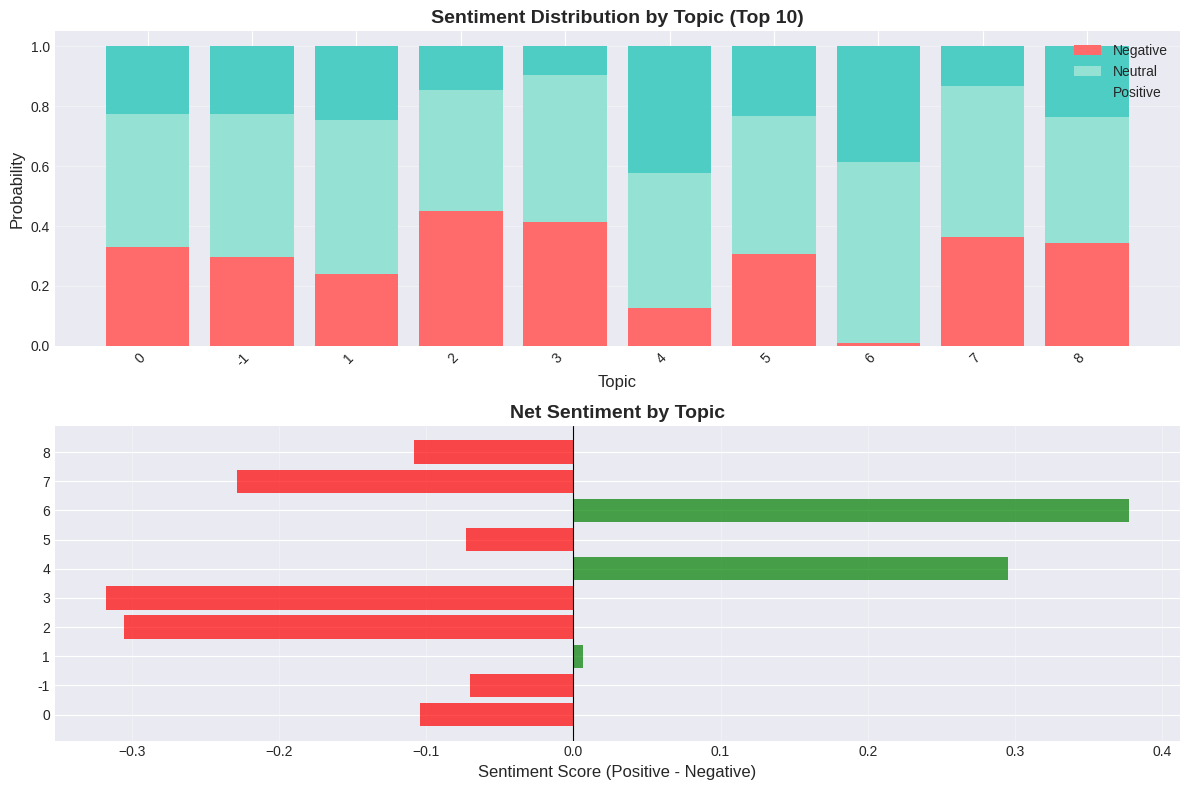

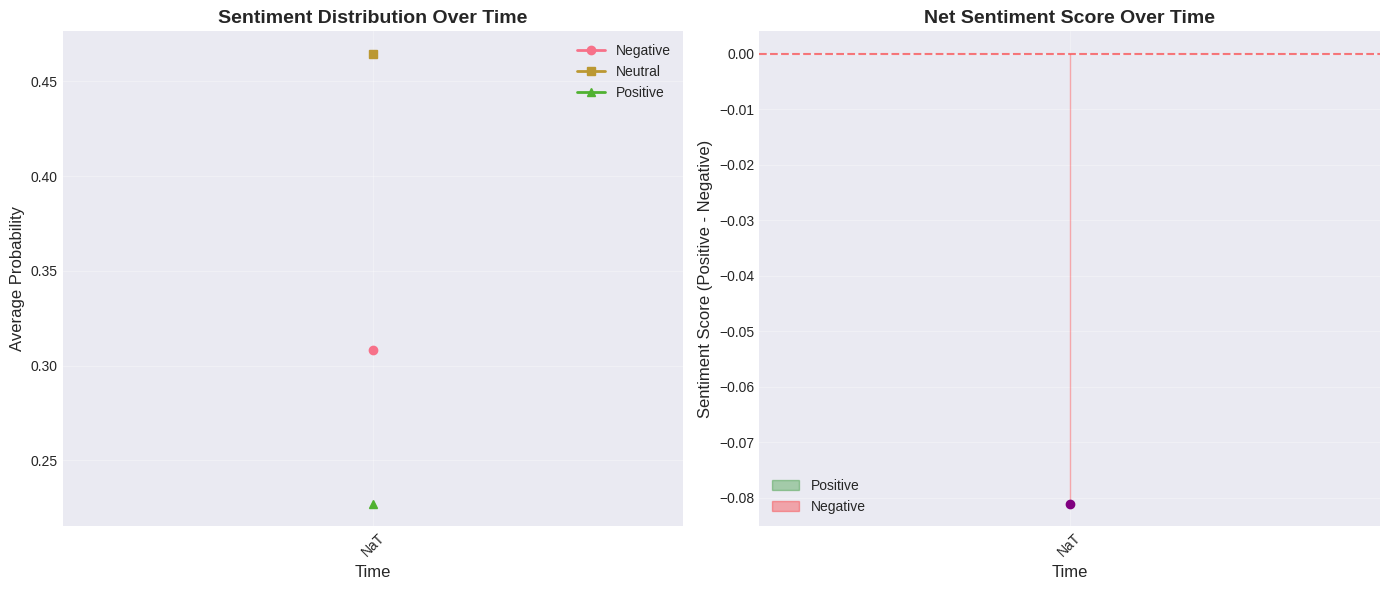

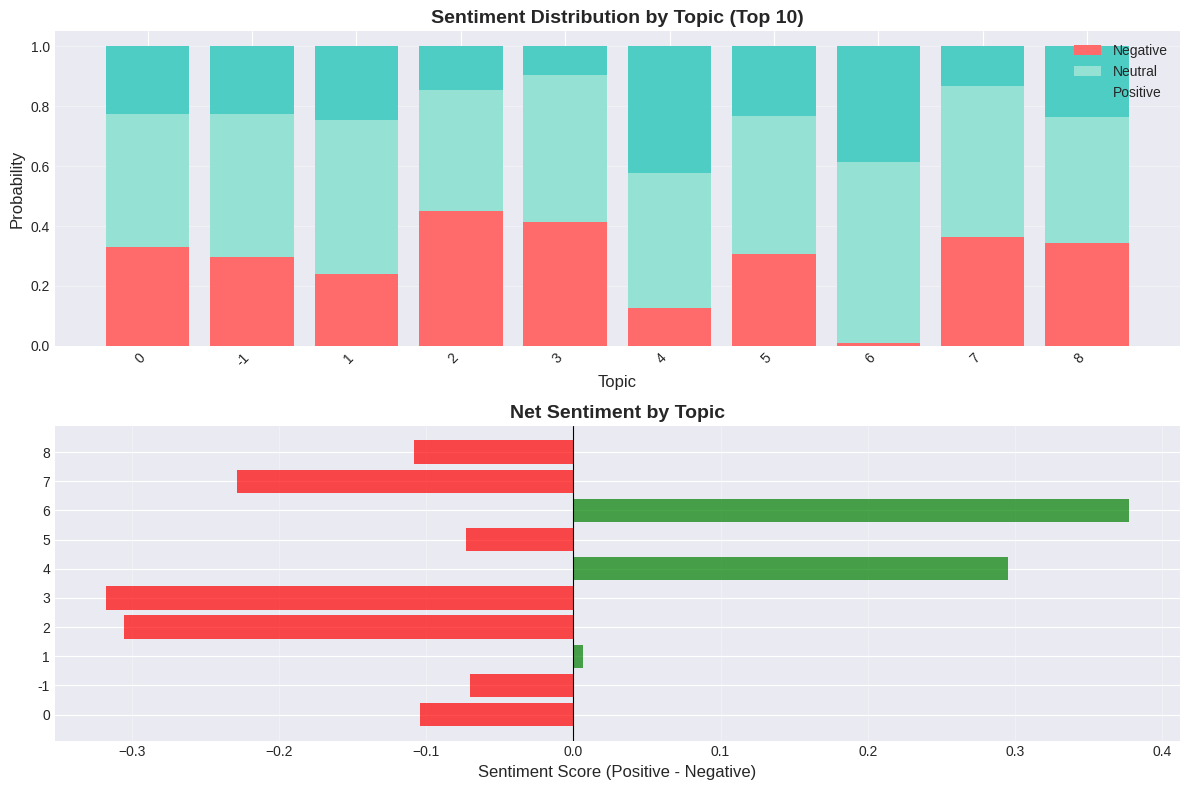

In [10]:
# 3. 生成可视化
visualizer = SentimentVisualizer(df_analyzed)
visualizer.plot_sentiment_over_time(time_column='quarter')
visualizer.plot_sentiment_by_topic(topic_column='Topic')

In [11]:
topic_counts = df['Top_n_words'].value_counts()

topic_counts

Top_n_words
nvidia - copyright - amd - agi - gpu - intel - artists - gpus - altman - musk                                           2292
homework - min - hee - translation - jin - lawsuit - assignment - tesla - exclusive - artists                           2025
ships - characters - combat - species - sag - weapons - planet - weapon - enemy - vas                                    489
cover letter - resumes - supervisor - applicants - recruiters - recruiter - ats - pip - rto - cover letters              392
trumps - president - epstein - election - democrats - russia - republicans - maga - voters - musk                        264
palantir - dd - sec - hiv - valuation - ipo - hive - rail - market cap - crypto                                          220
essay - professors - essays - semester - grades - prof - assignment - pw - gpa - universities                            213
beginners - mastering - mastery - masterclass - diploma - bootcamp - beginner - java - wordpress - javascript    